# Topic: Netflix - Enhanced Content Recommendations System

Python modules requried for the project

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot, Dense, Concatenate
from tensorflow.keras.models import Model

In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = '/content'

In [ ]:
!kaggle datasets download -d paramvir705/netflix-dataset
!unzip netflix-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/paramvir705/netflix-dataset
License(s): apache-2.0
Archive:  netflix-dataset.zip
  inflating: netflix_titles.csv      


In [ ]:
netflix_df = pd.read_csv('netflix_titles.csv')
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Data cleaning and preprocessing to remove missing data

In [ ]:
def clean_data(df):
    """
    Comprehensive data cleaning for Netflix dataset with proper error handling
    """
    print("\n=== Missing Values Before Cleaning ===")
    print(df.isnull().sum())

    try:
        # Handle missing values - text columns
        text_columns = ['director', 'cast', 'country']
        df[text_columns] = df[text_columns].fillna('Unknown')

        # Handle missing values - critical columns (drop if missing)
        critical_columns = ['rating', 'duration', 'date_added']
        df = df.dropna(subset=critical_columns, how='any')

        # Convert date_added to datetime with error handling
        df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
        df = df.dropna(subset=['date_added'])  # Drop rows with invalid dates

        # Duration processing with error handling
        df['duration_num'] = df['duration'].str.extract('(\d+)', expand=False).astype(float)

        # Handle cases where duration format is unexpected
        df['duration_unit'] = np.where(
            df['duration'].str.contains('min', case=False, na=False),
            'min',
            np.where(
                df['duration'].str.contains('season', case=False, na=False),
                'season',
                'unknown'
            )
        )

        # Clean and split genres
        df['listed_in'] = df['listed_in'].str.strip().str.split(',\s*')

        # Create unique content IDs
        df['content_id'] = range(1, len(df)+1)

        # Final validation
        if df.isnull().sum().sum() > 0:
            raise ValueError("Null values still present after cleaning")

        print("\n=== Missing Values After Cleaning ===")
        print(df.isnull().sum())
        print(f"\nFinal dataset shape: {df.shape}")

        return df

    except Exception as e:
        print(f"\nError during cleaning: {str(e)}")
        # Return partially cleaned data for debugging
        return df

netflix_df = clean_data(netflix_df)


=== Missing Values Before Cleaning ===
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

=== Missing Values After Cleaning ===
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added       0
release_year     0
rating           0
duration         0
listed_in        0
description      0
duration_num     0
duration_unit    0
content_id       0
dtype: int64

Final dataset shape: (8702, 15)


<ipython-input-6-fe9cf90c2df0>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


## Exploring the dataset

Exploring the dataset based on
1. Basic Dataset Overview
2. Distribution of content on Netflix
3. Content added by year and type
4. Rating system Analysis
5. Duration Analysis by type in Netflix
6. top 20 content processing countries
7. genre analysis of words
8. Content Added to Netflix every year
9. Directors contribution analysis
10. Content added per month


=== NETFLIX CONTENT ANALYSIS ===

1. Dataset Overview:
Total Records: 8702
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'duration_num', 'duration_unit', 'content_id']
Time Range: 1925 to 2021


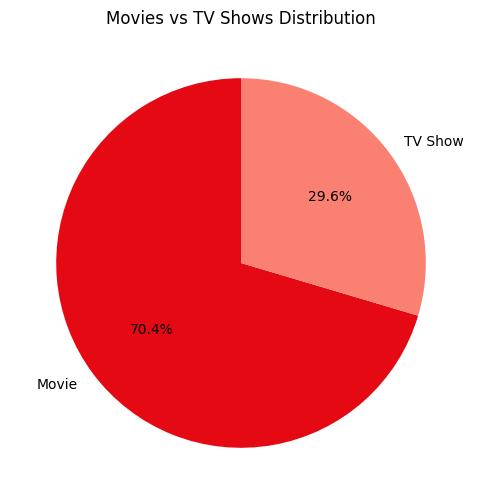

<Figure size 1400x700 with 0 Axes>

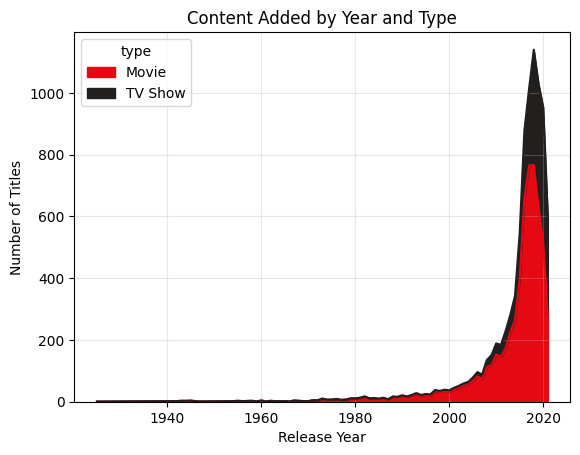

<ipython-input-7-d08d8406589b>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='rating', order=rating_order,


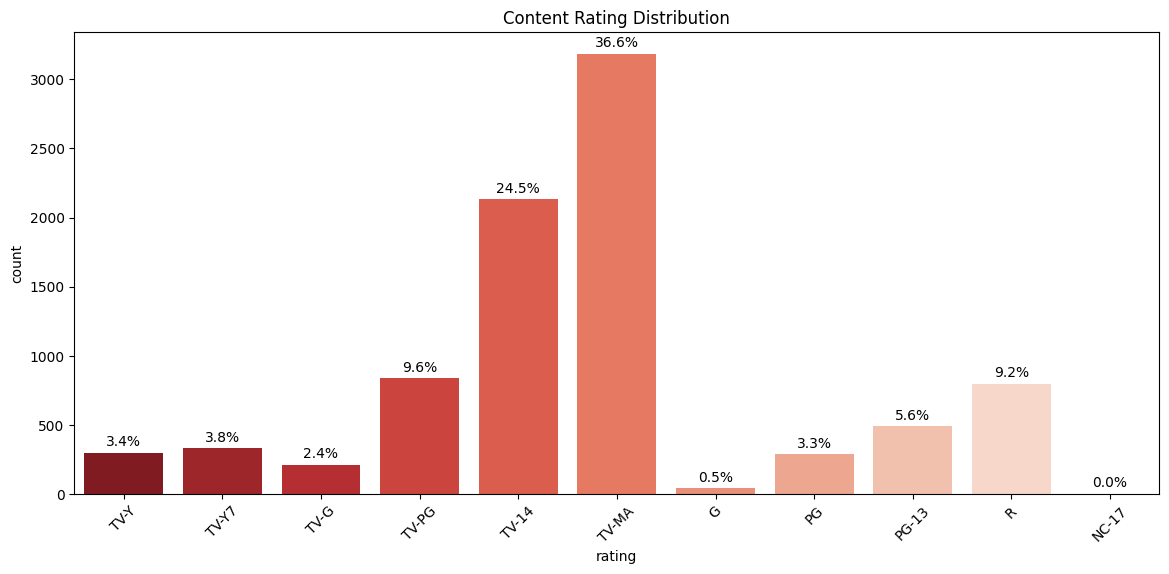

<ipython-input-7-d08d8406589b>:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_num'] = movies['duration_num'].astype(float)
<ipython-input-7-d08d8406589b>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shows['duration_num'] = shows['duration_num'].astype(float)


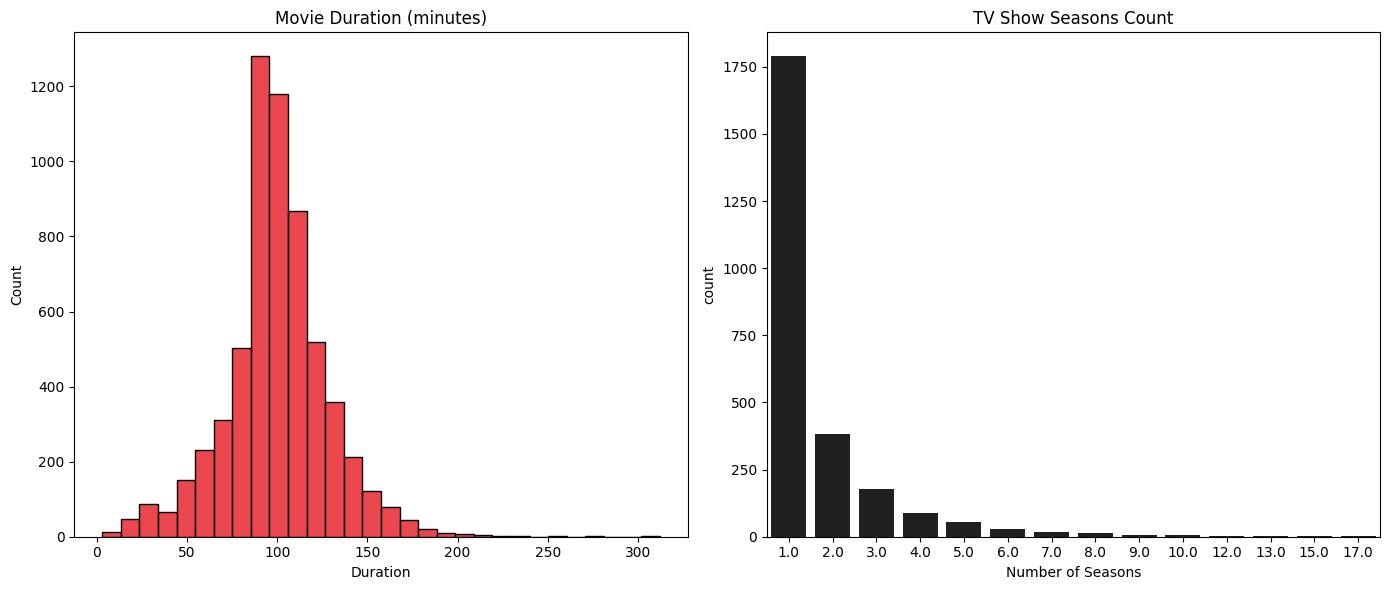

<ipython-input-7-d08d8406589b>:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='Reds_r')


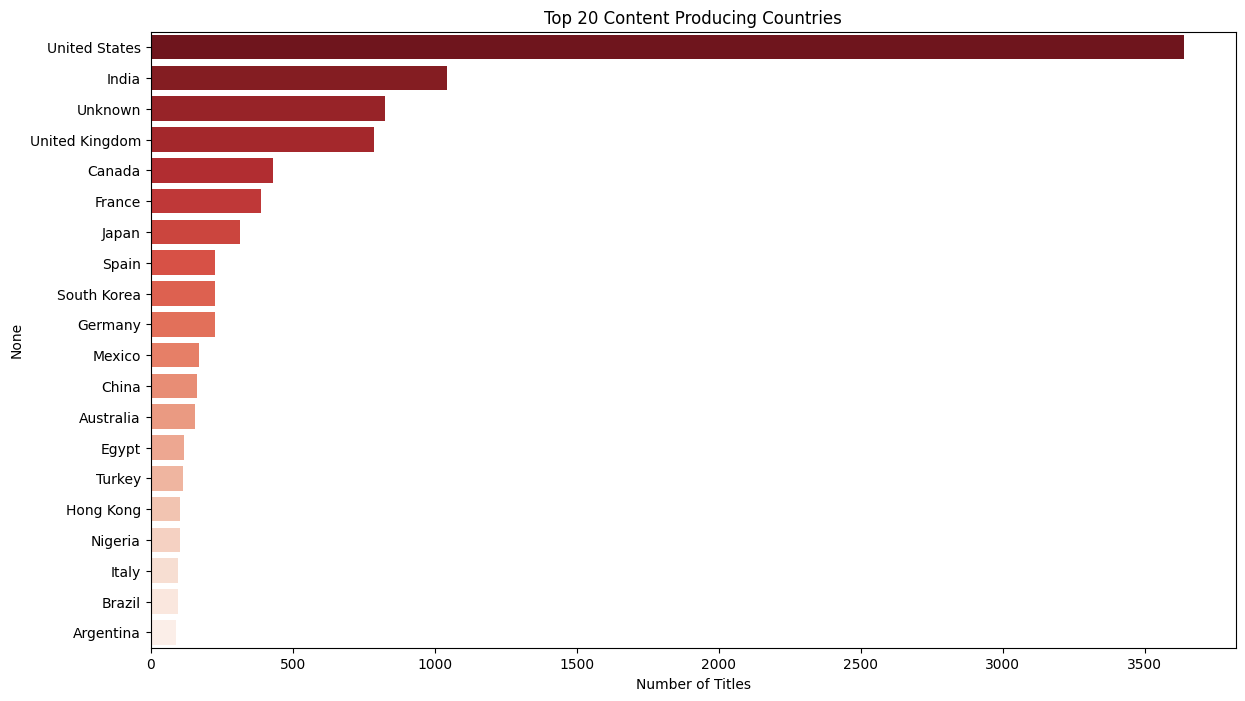

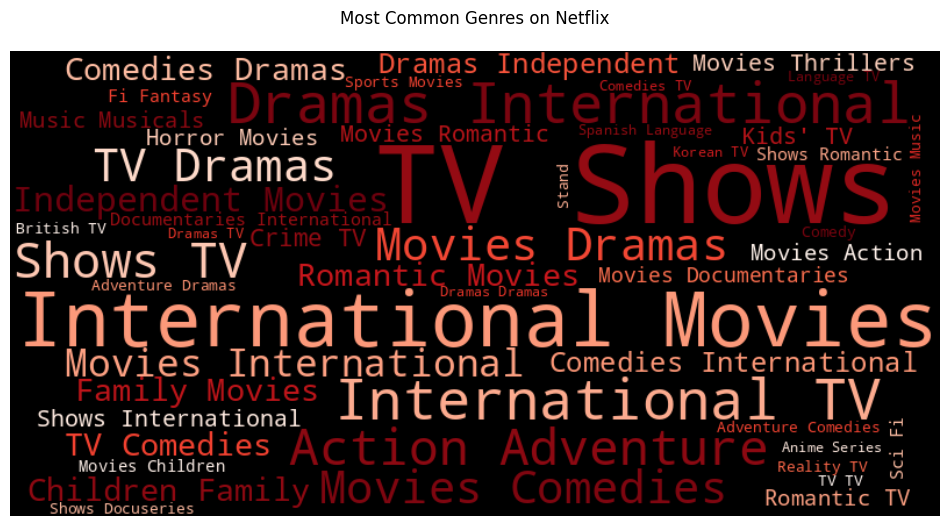

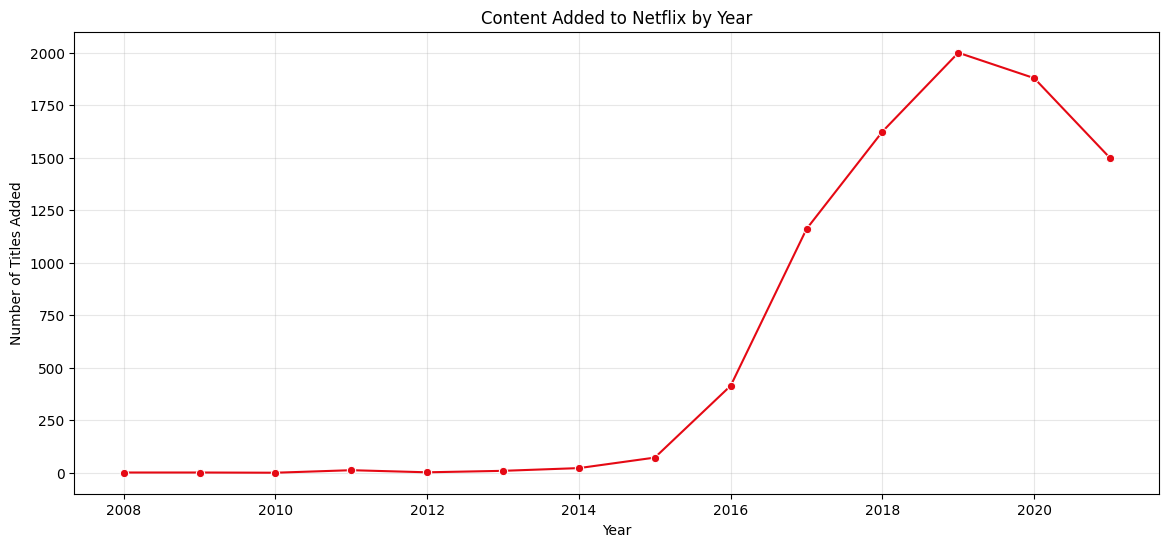

<ipython-input-7-d08d8406589b>:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='Reds_r')


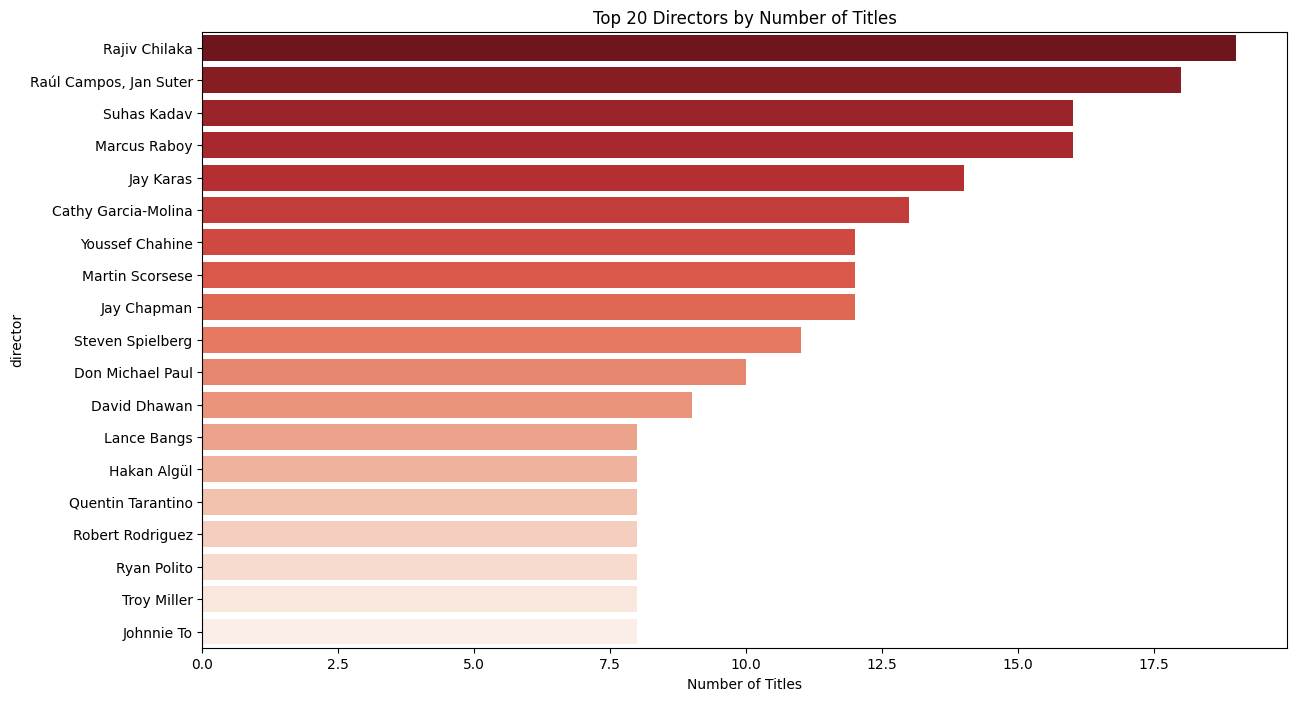

<ipython-input-7-d08d8406589b>:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_additions.index, y=monthly_additions.values,


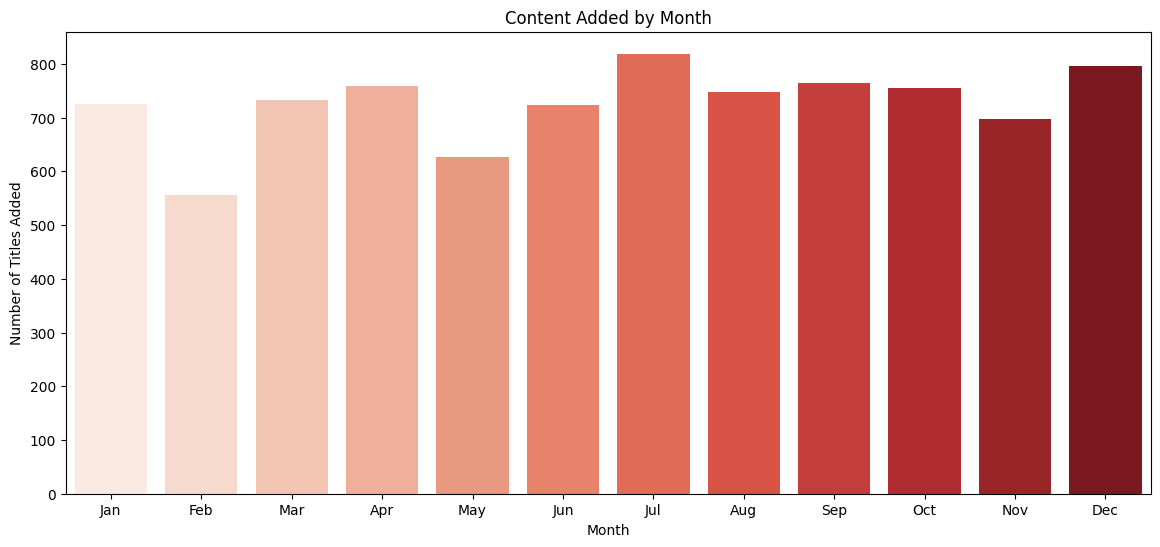

In [ ]:
def perform_eda(df):
    print("\n=== NETFLIX CONTENT ANALYSIS ===")

    # 1.
    print("\n1. Dataset Overview:")
    print(f"Total Records: {len(df)}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Time Range: {df['release_year'].min()} to {df['release_year'].max()}")

    # 2.
    plt.figure(figsize=(10,6))
    type_counts = df['type'].value_counts()
    plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#E50914', 'salmon'], startangle=90)
    plt.title("Movies vs TV Shows Distribution")
    plt.show()

    # 3.
    plt.figure(figsize=(14,7))
    yearly_content = df.groupby(['release_year', 'type']).size().unstack()
    yearly_content.plot(kind='area', stacked=True, color=['#E50914', '#221F1F'])
    plt.title("Content Added by Year and Type")
    plt.xlabel("Release Year")
    plt.ylabel("Number of Titles")
    plt.grid(True, alpha=0.3)
    plt.show()

    # 4.
    plt.figure(figsize=(14,6))
    rating_order = ['TV-Y', 'TV-Y7', 'TV-G', 'TV-PG', 'TV-14', 'TV-MA',
                   'G', 'PG', 'PG-13', 'R', 'NC-17']
    ax = sns.countplot(data=df, x='rating', order=rating_order,
                      palette='Reds_r')
    plt.title("Content Rating Distribution")
    plt.xticks(rotation=45)

    # Add percentage annotations to show in plotted graph
    total = len(df)
    for p in ax.patches:
        percentage = f'{100 * p.get_height()/total:.1f}%'
        x = p.get_x() + p.get_width()/2
        y = p.get_height()+50
        ax.annotate(percentage, (x, y), ha='center')
    plt.show()

    # 5.
    plt.figure(figsize=(14,6))

    # Movies duration
    movies = df[df['type'] == 'Movie']
    movies['duration_num'] = movies['duration_num'].astype(float)
    plt.subplot(1,2,1)
    sns.histplot(movies['duration_num'], bins=30, color='#E50914')
    plt.title("Movie Duration (minutes)")
    plt.xlabel("Duration")

    # TV Shows seasons
    shows = df[df['type'] == 'TV Show']
    shows['duration_num'] = shows['duration_num'].astype(float)
    plt.subplot(1,2,2)
    sns.countplot(data=shows, x='duration_num', color='#221F1F')
    plt.title("TV Show Seasons Count")
    plt.xlabel("Number of Seasons")

    plt.tight_layout()
    plt.show()

    # 6.
    plt.figure(figsize=(14,8))
    country_counts = df['country'].str.split(', ', expand=True).stack().value_counts().head(20)
    sns.barplot(x=country_counts.values, y=country_counts.index, palette='Reds_r')
    plt.title("Top 20 Content Producing Countries")
    plt.xlabel("Number of Titles")
    plt.show()

    # 7.
    # Combining all genres present in the netflix_df
    all_genres = ' '.join(df['listed_in'].explode().dropna())

    plt.figure(figsize=(12,8))
    wordcloud = WordCloud(width=800, height=400,
                         background_color='black',
                         colormap='Reds',
                         max_words=50).generate(all_genres)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Most Common Genres on Netflix", pad=20)
    plt.show()

    # 8.
    df['date_added_year'] = df['date_added'].dt.year
    plt.figure(figsize=(14,6))
    added_yearly = df['date_added_year'].value_counts().sort_index()
    sns.lineplot(x=added_yearly.index, y=added_yearly.values,
                 color='#E50914', marker='o')
    plt.title("Content Added to Netflix by Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Titles Added")
    plt.grid(True, alpha=0.3)
    plt.show()

    # 9.
    plt.figure(figsize=(14,8))
    top_directors = df['director'].value_counts().head(20)[1:]  # Exclude 'Unknown' missing datas
    sns.barplot(x=top_directors.values, y=top_directors.index, palette='Reds_r')
    plt.title("Top 20 Directors by Number of Titles")
    plt.xlabel("Number of Titles")
    plt.show()

    # 10.
    df['date_added_month'] = df['date_added'].dt.month
    plt.figure(figsize=(14,6))
    monthly_additions = df.groupby('date_added_month').size()
    sns.barplot(x=monthly_additions.index, y=monthly_additions.values,
                palette='Reds')
    plt.title("Content Added by Month")
    plt.xlabel("Month")
    plt.ylabel("Number of Titles Added")
    plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.show()

perform_eda(netflix_df)

## using sentiment analysis for content based recommendation component, using only machine learning

In [ ]:
def build_content_based_model(df):
    # Ensure VADER lexicon is downloaded
    try:
        nltk.download('vader_lexicon', quiet=True)
        sia = SentimentIntensityAnalyzer()
    except Exception as e:
        print(f"Sentiment analysis initialization failed: {e}")
        # Fallback: Use simple word count if sentiment fails
        sia = None

    # Add sentiment scores if analyzer is available
    if sia:
        df['description_sentiment'] = df['description'].apply(
            lambda x: sia.polarity_scores(str(x))['compound'])
        print("Successfully added sentiment analysis")
    else:
        df['description_sentiment'] = 0
        print("Using neutral sentiment as fallback")

    # TF-IDF Vectorization with error handling
    try:
        tfidf = TfidfVectorizer(stop_words='english', min_df=3, max_df=0.7)
        tfidf_matrix = tfidf.fit_transform(df['description'].fillna(''))
        cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
        print("TF-IDF matrix created successfully")
    except Exception as e:
        print(f"TF-IDF failed: {e}")
        # Create dummy similarity matrix if TF-IDF fails
        cosine_sim = np.eye(len(df))

    # Create indices for title lookup
    indices = pd.Series(df.index, index=df['title'].str.lower()).drop_duplicates()

    def get_recommendations(title, n=10, similarity_threshold=0.1):
        try:
            # Case-insensitive title matching
            title_lower = str(title).lower()
            idx = indices[title_lower]

            # Get pairwise similarity scores
            sim_scores = list(enumerate(cosine_sim[idx]))

            # Filter by similarity threshold
            sim_scores = [i for i in sim_scores if i[1] > similarity_threshold]

            # Sort by similarity score
            sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

            # Get top N recommendations (excluding itself)
            sim_scores = sim_scores[1:n+1]
            movie_indices = [i[0] for i in sim_scores]

            # Return recommendations with similarity scores
            recommendations = df.iloc[movie_indices].copy()
            recommendations['similarity_score'] = [i[1] for i in sim_scores]

            return recommendations

        except KeyError:
            print(f"Title '{title}' not found in dataset. Showing popular items instead.")
            return df.sample(n)
        except Exception as e:
            print(f"Error: {e}")
            return pd.DataFrame()

    return get_recommendations

# Initialize the recommender
content_recommender = build_content_based_model(netflix_df)

# Test the recommender
print("\nTesting recommendation system...")
test_recommendations = content_recommender("Stranger Things")
if not test_recommendations.empty:
    print("\nSuccessful recommendations:")
    print(test_recommendations[['title', 'type', 'rating', 'similarity_score']].head())
else:
    print("Recommendation system failed - showing random samples")
    print(netflix_df.sample(5)[['title', 'type', 'rating']])

Successfully added sentiment analysis
TF-IDF matrix created successfully

Testing recommendation system...

Successful recommendations:
                        title     type rating  similarity_score
4733            Rowdy Rathore    Movie  TV-14          0.316599
8198  The Autopsy of Jane Doe    Movie      R          0.269194
1240               Safe Haven    Movie  PG-13          0.232141
1487          Sakho & Mangane  TV Show  TV-MA          0.220418
2419            Big Stone Gap    Movie  PG-13          0.196864


## Developing a Deep learning Collaborative filtering model

In [ ]:
def build_deep_learning_model(df):
    # Create user-item matrix (simulated since we don't have real user data)
    # Create simulated users and ratings
    num_users = 1000
    num_items = len(df)

    # Generate random user-item interactions
    user_ids = np.random.randint(0, num_users, size=num_items*10)
    item_ids = np.random.randint(0, num_items, size=num_items*10)
    ratings = np.random.randint(1, 6, size=num_items*10)

    # Create DataFrame of simulated interactions
    interactions = pd.DataFrame({
        'user_id': user_ids,
        'content_id': item_ids,
        'rating': ratings
    })

    # Neural Collaborative Filtering Model
    user_input = Input(shape=(1,), name='user_input')
    item_input = Input(shape=(1,), name='item_input')

    user_embedding = Embedding(num_users, 50, name='user_embedding')(user_input)
    item_embedding = Embedding(num_items, 50, name='item_embedding')(item_input)

    user_vec = Flatten()(user_embedding)
    item_vec = Flatten()(item_embedding)

    concat = Concatenate()([user_vec, item_vec])
    dense = Dense(128, activation='relu')(concat)
    dense = Dense(64, activation='relu')(dense)
    output = Dense(1, activation='linear')(dense)

    model = Model(inputs=[user_input, item_input], outputs=output)
    model.compile(optimizer='adam', loss='mse')

    # Train the model (using simulated data)
    X = [interactions['user_id'], interactions['content_id']]
    y = interactions['rating']
    model.fit(X, y, batch_size=64, epochs=20, validation_split=0.2)

    return model

dl_model = build_deep_learning_model(netflix_df)

Epoch 1/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 3.1325 - val_loss: 2.0371
Epoch 2/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.9628 - val_loss: 2.0671
Epoch 3/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.8071 - val_loss: 2.1483
Epoch 4/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.4199 - val_loss: 2.3990
Epoch 5/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.8696 - val_loss: 2.7320
Epoch 6/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.5133 - val_loss: 2.9528
Epoch 7/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3313 - val_loss: 3.1315
Epoch 8/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2393 - val_loss: 3.1577
Epoch 9/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1965 - val_loss: 3.2041
Epoch 10/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1764 - val_loss: 3.1827
Epoch 11/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1564 - val_loss: 3.1983
Epoch 12/20
1088/1088 ━━━━━━━

Developing a hybrid recommendation systen using sentimentanalysis and deep learning
where content similarities were combined and predicted the user ratings, aling with weighted scoring for balanced recommendation

In [ ]:
def hybrid_recommendation(user_id, title, n=10):
    # Content-based recommendations
    content_recs = content_recommender(title, n*2)
    content_ids = content_recs['content_id'].values

    # Predict ratings for these items using DL model
    user_array = np.array([user_id] * len(content_ids))
    predicted_ratings = dl_model.predict([user_array, content_ids]).flatten()

    # Combine with content similarity scores
    content_recs['predicted_rating'] = predicted_ratings
    content_recs['combined_score'] = 0.6 * content_recs['predicted_rating'] + 0.4 * content_recs.index

    # Return top N recommendations
    return content_recs.sort_values('combined_score', ascending=False).head(n)

In [ ]:
# Test content-based recommendations
print("\nContent-Based Recommendations for 'Stranger Things':")
print(content_recommender("Stranger Things")[['title', 'type', 'rating']])

# Test hybrid recommendations (using simulated user 42)
print("\nHybrid Recommendations for User 42 ('Stranger Things'):")
print(hybrid_recommendation(42, "Stranger Things")[['title', 'type', 'rating', 'predicted_rating']])


Content-Based Recommendations for 'Stranger Things':
                        title     type rating
4733            Rowdy Rathore    Movie  TV-14
8198  The Autopsy of Jane Doe    Movie      R
1240               Safe Haven    Movie  PG-13
1487          Sakho & Mangane  TV Show  TV-MA
2419            Big Stone Gap    Movie  PG-13
4201              Hardy Bucks  TV Show  TV-MA
6518         Come and Find Me    Movie      R
273             Gone for Good  TV Show  TV-MA
5150              Broadchurch  TV Show  TV-MA
6760                FirstBorn    Movie  TV-MA

Hybrid Recommendations for User 42 ('Stranger Things'):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
                              title     type rating  predicted_rating
8198        The Autopsy of Jane Doe    Movie      R          2.339452
8026                Sinister Circle    Movie  TV-MA          3.886160
7155                              K  TV Show  TV-MA          3.459749
6760                      FirstBorn    Movie  TV-MA          4.2

## **Evaluated Recommendation**

In [ ]:
def evaluate_recommendations(recommendations):
    print("\nRecommendation Quality Metrics:")
    print(f"Average Predicted Rating: {recommendations['predicted_rating'].mean():.2f}")
    print(f"Rating Diversity: {recommendations['rating'].nunique()} unique ratings")
    print(f"Content Types: {recommendations['type'].value_counts().to_dict()}")

evaluate_recommendations(hybrid_recommendation(42, "Stranger Things"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Recommendation Quality Metrics:
Average Predicted Rating: 2.91
Rating Diversity: 4 unique ratings
Content Types: {'Movie': 6, 'TV Show': 4}


Using users interactive data to recommend further

In [ ]:
def get_user_recommendations():
    """Interactive function to get recommendations based on user input"""
    while True:
        print("\n" + "="*50)
        print("NETFLIX RECOMMENDATION ENGINE")
        print("="*50)

        # Get user input
        last_watched = input("\nWhat was the last title you watched? (or 'q' to quit): ").strip()

        if last_watched.lower() == 'q':
            print("Goodbye! Come back for more recommendations later.")
            break

        # Get recommendations
        print(f"\nBecause you watched '{last_watched}', we recommend:")

        # First try hybrid recommendations
        try:
            # Use a default user_id (42) since we're not tracking users
            hybrid_recs = hybrid_recommendation(42, last_watched, 5)
            if not hybrid_recs.empty:
                print(hybrid_recs[['title', 'type', 'rating']])
            else:
                raise ValueError("No hybrid recommendations")

        except:
            # Fallback to content-based if hybrid fails
            print("(Showing content-based recommendations)")
            content_recs = content_recommender(last_watched, 5)
            print(content_recs[['title', 'type', 'rating']])

        # Show evaluation metrics if available
        try:
            if 'predicted_rating' in hybrid_recs.columns:
                evaluate_recommendations(hybrid_recs)
        except:
            pass

        # Optional: Ask for feedback to improve system
        feedback = input("\nWas this helpful? (y/n): ").lower()
        if feedback == 'y':
            print("Great! Enjoy your viewing!")
        else:
            print("We'll try to improve our recommendations for next time!")

if __name__ == "__main__":
    # Start the interactive recommendation system
    get_user_recommendations()


NETFLIX RECOMMENDATION ENGINE

What was the last title you watched? (or 'q' to quit): Strang Things

Because you watched 'Strang Things', we recommend:
Title 'Strang Things' not found in dataset. Showing popular items instead.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
                                                  title   type rating
8210  The Bill Murray Stories: Life Lessons Learned ...  Movie  TV-MA
7087                                    Into the Forest  Movie      R
5644                            Rampage: President Down  Movie  TV-MA
3574                            Simon Amstell: Set Free  Movie  TV-MA
2799                          Altered Carbon: Resleeved  Movie  TV-MA

Recommendation Quality Metrics:
Average Predicted Rating: 2.65
Rating Diversity: 2 unique ratings
Content Types: {'Movie': 5}

Was this helpful? (y/n): y
Great! Enjoy your viewing!

NETFLIX RECOMMENDATION ENGINE

What was the last title you watched? (or 'q' to quit): dark

Because you watched 'dark', we recomme